# 📊 So Sánh 4 Phương Án Chia Block — Train / Val / Test

| Block | Tổng | Train | Val | Test |
|:---|:---:|:---:|:---:|:---:|
| **A. Block 7 ngày** | 168h | 5 ngày (120h) | 1 ngày (24h) | 1 ngày (24h) |
| **B. Block 5 ngày** | 120h | 3 ngày (72h) | 1 ngày (24h) | 1 ngày (24h) |
| **C. Block 1 ngày** | 24h | 3×6h train (18h) | 3×1h (3h) | 3×1h (3h) |
| **D. Block 30 ngày** | 720h | 20 ngày (480h) | 5 ngày (120h) | 5 ngày (120h) |

**Mục tiêu**: So sánh MAE/Mean naive, correlation Train-Test, seasonal coverage, và phân bố PM2.5 trong Test set.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

SELECTED = [1,2,3,4,5,6,7,16,17,18,24,27,28,30,31,32]
NORTH = [1,2,3,4,5,6,16,17,27,28]
SOUTH = [7,18,24,30,31,32]

all_air = {}
for sid in SELECTED:
    df = pd.read_csv(f'data/raw/air/air_{sid}.csv')
    df['datetime'] = pd.to_datetime(df['timestamp_local'])
    df = df.set_index('datetime').sort_index()
    all_air[sid] = df['pm25'].copy()

info_map = {
    1:'Cau Giay',2:'Thanh Xuan',3:'Tay Ho',4:'Tho Xuan',5:'Gia Lam',
    6:'Ba Vi',7:'Q1-HCM',16:'Do Son',17:'Hong Bang',18:'Ninh Kieu',
    24:'Bien Hoa',27:'Nam Dinh',28:'TP.TH',30:'Vinh Long',31:'Tra Vinh',32:'Rach Gia'
}

REPR = [1, 6, 7, 18, 24, 32]  # Representative stations
print(f"Loaded {len(all_air)} stations, time: {all_air[1].index.min()} -> {all_air[1].index.max()}")


Loaded 16 stations, time: 2023-01-01 00:00:00 -> 2025-12-01 00:00:00


## 1. Xây dựng hàm đánh giá cho mỗi Block

In [2]:

BLOCKS = {
    'A: 7d (5/1/1)': {'train_h': 5*24, 'val_h': 1*24, 'test_h': 1*24, 'color': '#e74c3c'},
    'B: 5d (3/1/1)': {'train_h': 3*24, 'val_h': 1*24, 'test_h': 1*24, 'color': '#2ecc71'},
    'C: 1d (6/1/1)x3': {'train_h': 6, 'val_h': 1, 'test_h': 1, 'color': '#3498db', 'repeats': 3},
    'D: 30d (20/5/5)': {'train_h': 20*24, 'val_h': 5*24, 'test_h': 5*24, 'color': '#9b59b6'},
}

def evaluate_block(pm_series, train_h, val_h, test_h, repeats=1):
    pm = pm_series.dropna()
    vals = pm.values
    idx = pm.index
    block_h = (train_h + val_h + test_h) * repeats
    
    naive_mae_tests = []
    train_means = []
    test_means = []
    test_months = []
    test_values_all = []
    train_values_all = []
    n_blocks = 0
    
    for start in range(0, len(vals) - block_h, block_h):
        block_vals = vals[start:start + block_h]
        block_idx = idx[start:start + block_h]
        if len(block_vals) < block_h:
            break
        
        all_train = []
        all_test = []
        
        for r in range(repeats):
            offset = r * (train_h + val_h + test_h)
            train = block_vals[offset:offset+train_h]
            val = block_vals[offset+train_h:offset+train_h+val_h]
            test = block_vals[offset+train_h+val_h:offset+train_h+val_h+test_h]
            all_train.extend(train)
            all_test.extend(test)
        
        last_train = all_train[-1]
        train_mean = np.mean(all_train)
        
        naive_mae = np.mean(np.abs(np.array(all_test) - last_train))
        naive_mae_tests.append(naive_mae)
        train_means.append(train_mean)
        test_means.append(np.mean(all_test))
        test_values_all.extend(all_test)
        train_values_all.extend(all_train)
        
        # Season of test
        test_start_idx = start + train_h * repeats + val_h * repeats
        if test_start_idx < len(idx):
            test_months.append(idx[test_start_idx].month)
        
        n_blocks += 1
    
    if n_blocks == 0:
        return None
    
    corr = np.corrcoef(train_means, test_means)[0, 1] if n_blocks > 1 else 0
    mean_pm = pm.mean()
    mae_ratio = np.mean(naive_mae_tests) / mean_pm * 100
    
    season_counts = {'DJF': 0, 'MAM': 0, 'JJA': 0, 'SON': 0}
    for m in test_months:
        if m in [12,1,2]: season_counts['DJF'] += 1
        elif m in [3,4,5]: season_counts['MAM'] += 1
        elif m in [6,7,8]: season_counts['JJA'] += 1
        else: season_counts['SON'] += 1
    
    return {
        'n_blocks': n_blocks,
        'mae_ratio': mae_ratio,
        'naive_mae': np.mean(naive_mae_tests),
        'corr': corr,
        'mean_pm': mean_pm,
        'seasons': season_counts,
        'test_values': test_values_all,
        'train_values': train_values_all,
    }

print("Functions ready!")


Functions ready!


## 2. Kết quả Naive Baseline MAE/Mean — So sánh 4 Block

NAIVE BASELINE MAE/Mean (%) — Cang cao = cang tot (model co nhieu room de hoc)
Station         |    A: 7d (5/1/1) |    B: 5d (3/1/1) |  C: 1d (6/1/1)x3 |  D: 30d (20/5/5) | Best
----------------------------------------------------------------------------------------------------
S1  [BAC] Cau Giay |           54.1% |           50.7% |           37.2% |           63.9% | D
S2  [BAC] Thanh Xuan |           53.6% |           50.5% |           36.9% |           64.5% | D
S3  [BAC] Tay Ho   |           55.3% |           51.8% |           36.3% |           62.0% | D
S4  [BAC] Tho Xuan |           45.1% |           45.4% |           32.7% |           57.6% | D
S5  [BAC] Gia Lam  |           54.3% |           50.9% |           37.4% |           63.9% | D
S6  [BAC] Ba Vi    |           51.8% |           48.6% |           35.4% |           59.8% | D
S7  [NAM] Q1-HCM   |           34.4% |           25.5% |           12.8% |           36.7% | D
S16 [BAC] Do Son   |           59.8% |           61.7%

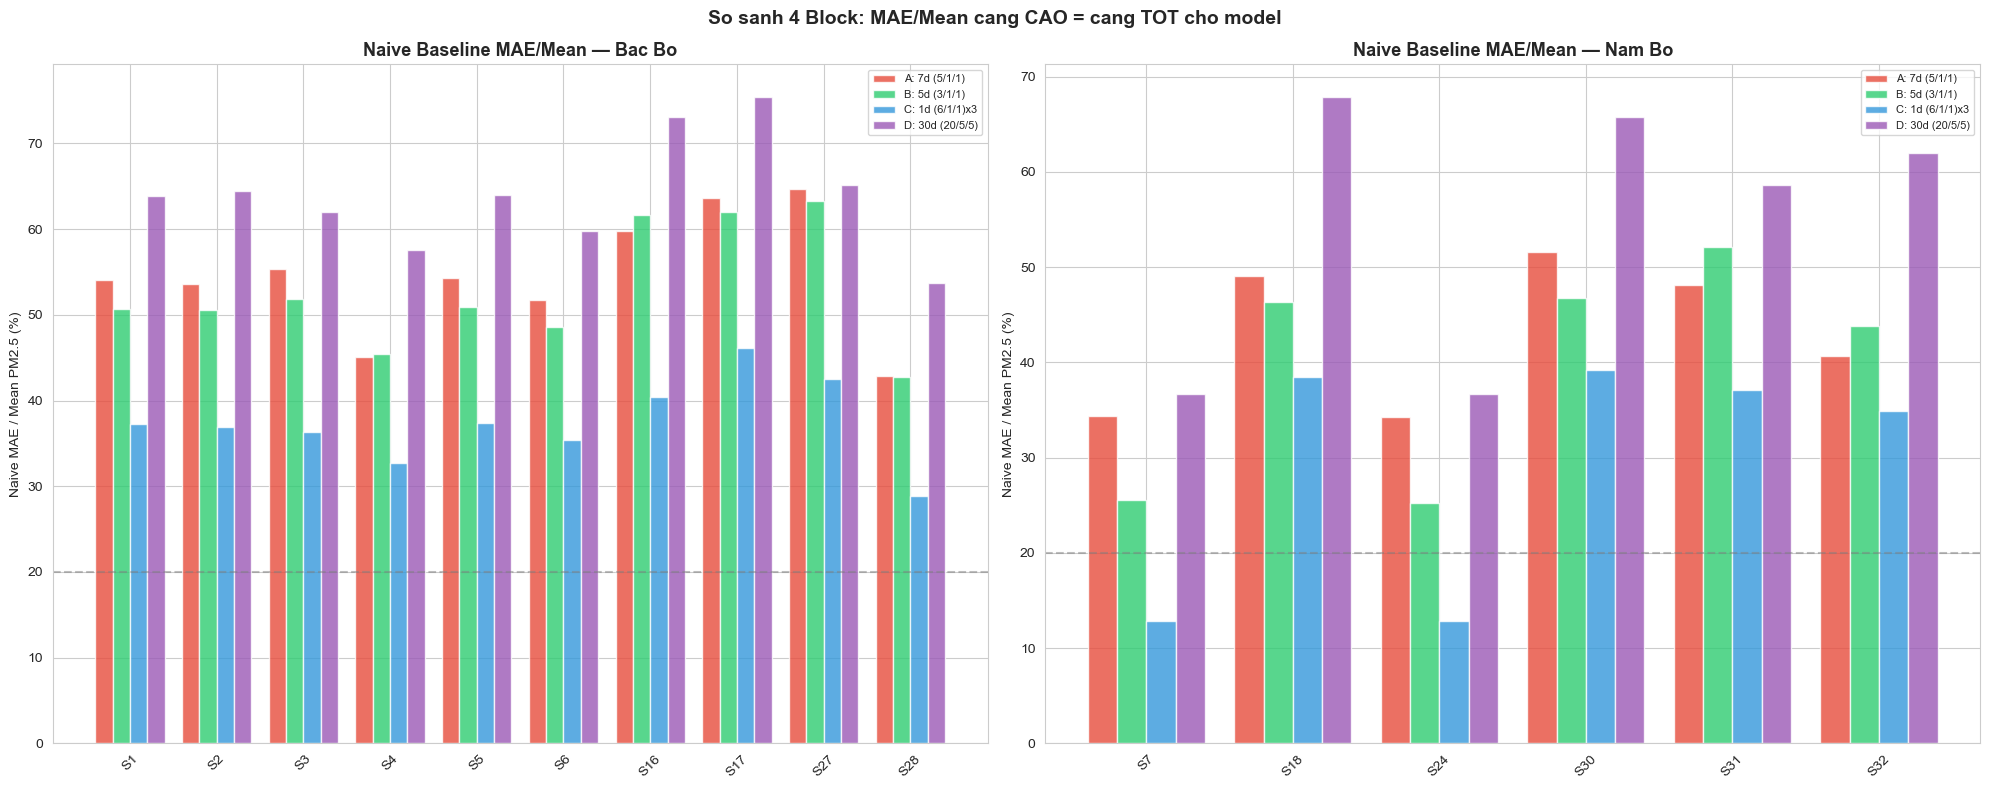

In [3]:

# === RUN ALL BLOCKS ON ALL STATIONS ===
all_results = {}
for bname, bconf in BLOCKS.items():
    all_results[bname] = {}
    repeats = bconf.get('repeats', 1)
    for sid in SELECTED:
        r = evaluate_block(all_air[sid], bconf['train_h'], bconf['val_h'], bconf['test_h'], repeats)
        all_results[bname][sid] = r

# === TABLE: MAE/Mean by Block x Station ===
print("=" * 100)
print("NAIVE BASELINE MAE/Mean (%) — Cang cao = cang tot (model co nhieu room de hoc)")
print("=" * 100)
header = f"{'Station':15s}"
for bname in BLOCKS:
    header += f" | {bname:>16s}"
header += " | Best"
print(header)
print("-" * 100)

for sid in SELECTED:
    cluster = "BAC" if sid in NORTH else "NAM"
    row = f"S{sid:<2d} [{cluster}] {info_map[sid]:8s}"
    ratios = {}
    for bname in BLOCKS:
        r = all_results[bname][sid]
        if r:
            row += f" | {r['mae_ratio']:14.1f}%"
            ratios[bname] = r['mae_ratio']
        else:
            row += f" | {'N/A':>15s}"
    
    best = max(ratios, key=ratios.get) if ratios else "N/A"
    row += f" | {best.split(':')[0]}"
    print(row)

# === BAR CHART ===
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, (label, ids) in zip(axes, [('Bac Bo', NORTH), ('Nam Bo', SOUTH)]):
    x = np.arange(len(ids))
    width = 0.2
    
    for i, (bname, bconf) in enumerate(BLOCKS.items()):
        vals = [all_results[bname][sid]['mae_ratio'] if all_results[bname][sid] else 0 for sid in ids]
        ax.bar(x + i*width, vals, width, label=bname, color=bconf['color'], alpha=0.8)
    
    ax.set_xticks(x + 1.5*width)
    ax.set_xticklabels([f"S{s}" for s in ids], rotation=45)
    ax.set_ylabel('Naive MAE / Mean PM2.5 (%)')
    ax.set_title(f'Naive Baseline MAE/Mean — {label}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)
    ax.axhline(y=20, color='gray', linestyle='--', alpha=0.5, label='Nguong 20%')

plt.suptitle('So sanh 4 Block: MAE/Mean cang CAO = cang TOT cho model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Tương Quan Train-Test — Kiểm tra Data Leakage

CORRELATION Train_mean vs Test_mean — Cang THAP = cang TOT (it leak)
Station         |    A: 7d (5/1/1) |    B: 5d (3/1/1) |  C: 1d (6/1/1)x3 |  D: 30d (20/5/5)
----------------------------------------------------------------------------------------------------
S1  [BAC] Cau Giay |          0.548 |          0.612 |          0.948 ! |          0.458
S2  [BAC] Thanh Xuan |          0.553 |          0.610 |          0.949 ! |          0.468
S3  [BAC] Tay Ho   |          0.557 |          0.663 |          0.954 !! |          0.500
S4  [BAC] Tho Xuan |          0.573 |          0.633 |          0.961 !! |          0.477
S5  [BAC] Gia Lam  |          0.543 |          0.615 |          0.947 ! |          0.447
S6  [BAC] Ba Vi    |          0.563 |          0.606 |          0.941 ! |          0.780
S7  [NAM] Q1-HCM   |          0.683 |          0.899 ! |          0.996 !! |          0.804
S16 [BAC] Do Son   |          0.632 |          0.560 |          0.948 ! |          0.514
S17 [BAC] Hong Bang

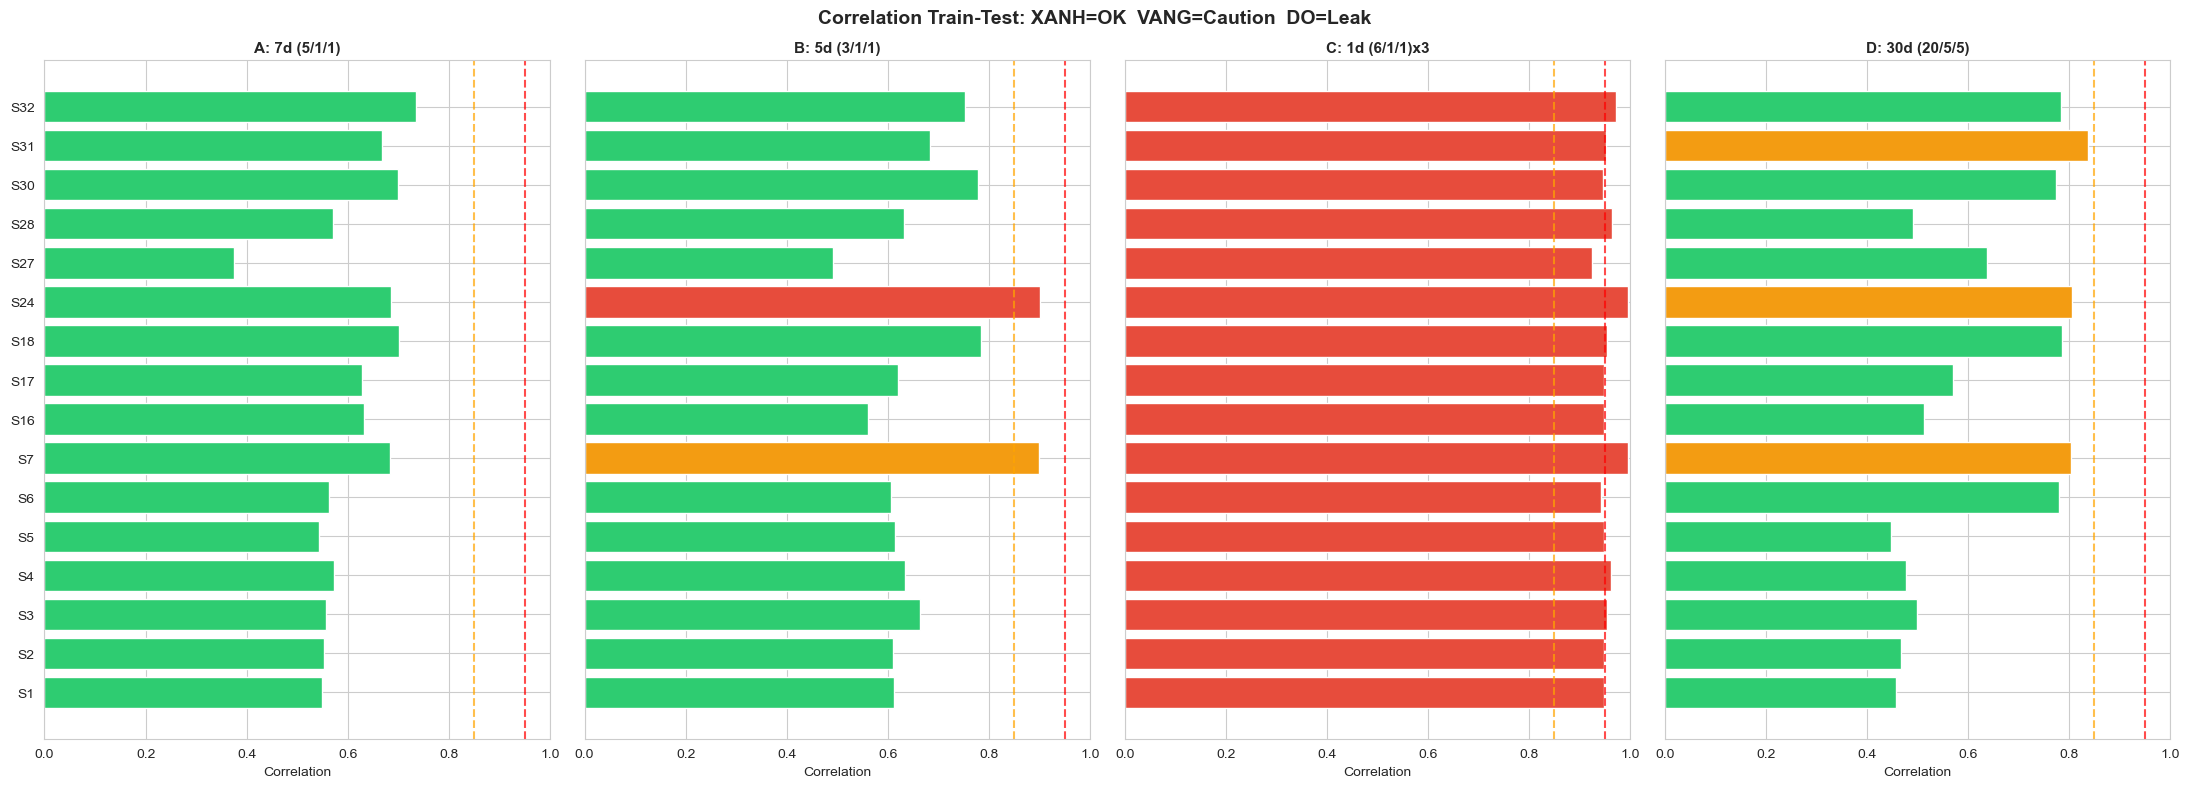

In [4]:

# === CORRELATION TABLE ===
print("=" * 100)
print("CORRELATION Train_mean vs Test_mean — Cang THAP = cang TOT (it leak)")
print("=" * 100)
header = f"{'Station':15s}"
for bname in BLOCKS:
    header += f" | {bname:>16s}"
print(header)
print("-" * 100)

for sid in SELECTED:
    cluster = "BAC" if sid in NORTH else "NAM"
    row = f"S{sid:<2d} [{cluster}] {info_map[sid]:8s}"
    for bname in BLOCKS:
        r = all_results[bname][sid]
        if r:
            corr = r['corr']
            flag = " !!" if corr > 0.95 else (" !" if corr > 0.85 else "")
            row += f" | {corr:14.3f}{flag}"
        else:
            row += f" | {'N/A':>16s}"
    print(row)

# === HEATMAP ===
fig, axes = plt.subplots(1, 4, figsize=(22, 8), sharey=True)

for ax, (bname, bconf) in zip(axes, BLOCKS.items()):
    corrs = [all_results[bname][sid]['corr'] if all_results[bname][sid] else 0 for sid in SELECTED]
    labels = [f"S{s}" for s in SELECTED]
    colors = ['#e74c3c' if c > 0.90 else ('#f39c12' if c > 0.80 else '#2ecc71') for c in corrs]
    ax.barh(range(len(SELECTED)), corrs, color=colors)
    ax.set_yticks(range(len(SELECTED)))
    ax.set_yticklabels(labels)
    ax.set_xlim(0, 1)
    ax.axvline(x=0.85, color='orange', linestyle='--', alpha=0.7)
    ax.axvline(x=0.95, color='red', linestyle='--', alpha=0.7)
    ax.set_title(bname, fontsize=11, fontweight='bold')
    ax.set_xlabel('Correlation')

plt.suptitle('Correlation Train-Test: XANH=OK  VANG=Caution  DO=Leak', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Phân Bố PM2.5 Trong Test Set — So Sánh 4 Block
Biểu đồ cho thấy Test set của mỗi phương án có phân bố PM2.5 như thế nào. Test set **tốt** = phải cover cả giá trị thấp (sạch) lẫn giá trị cao (ô nhiễm).


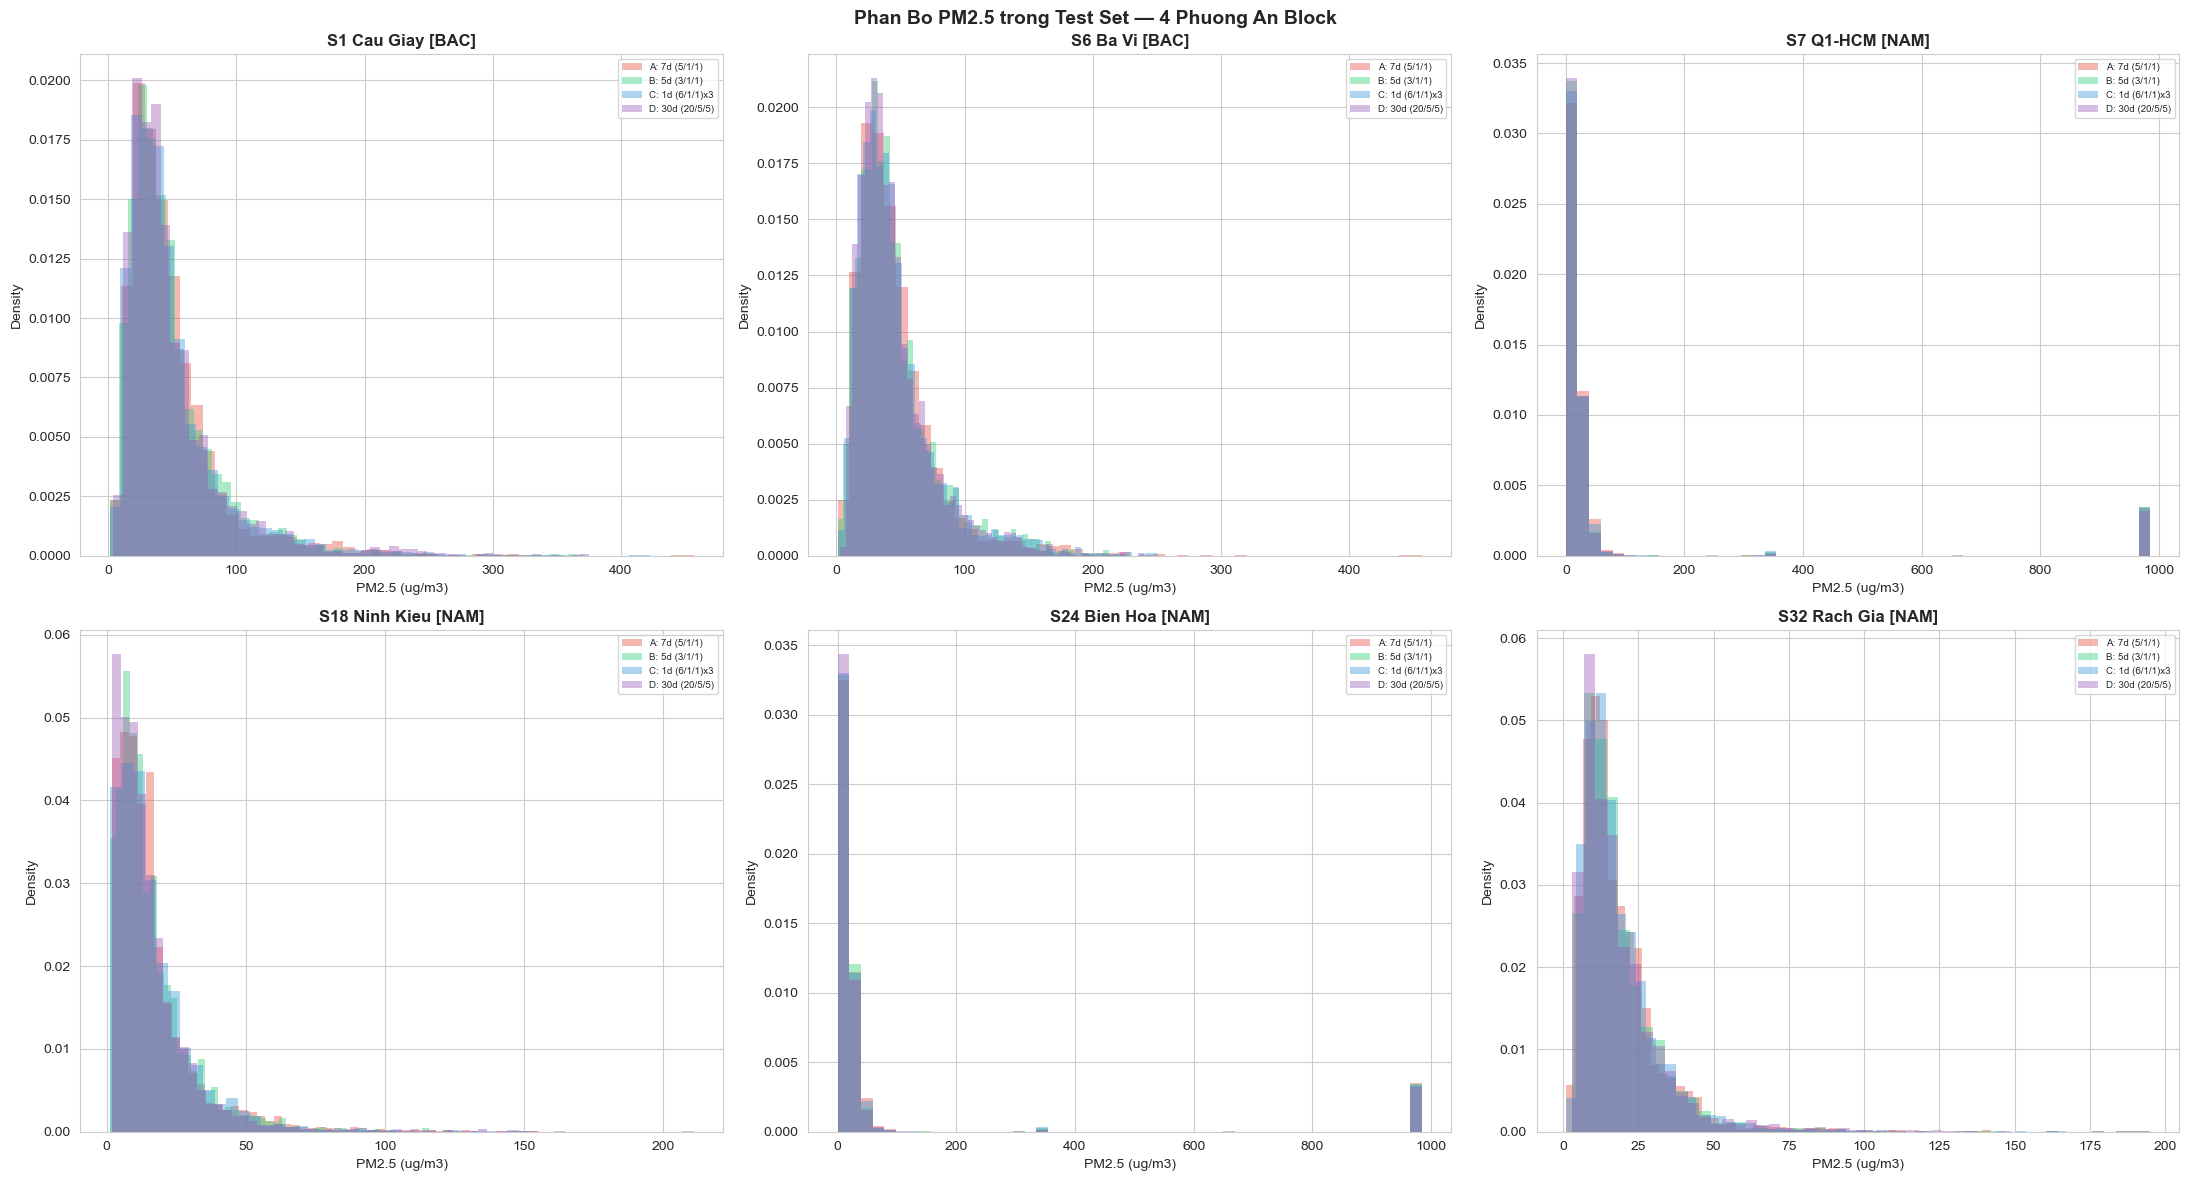

In [5]:

# === PM2.5 DISTRIBUTION IN TEST SET ===
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for i, sid in enumerate(REPR):
    ax = axes[i]
    cluster = "BAC" if sid in NORTH else "NAM"
    
    for bname, bconf in BLOCKS.items():
        r = all_results[bname][sid]
        if r and len(r['test_values']) > 0:
            ax.hist(r['test_values'], bins=50, alpha=0.4, label=bname, 
                    color=bconf['color'], density=True, edgecolor='none')
    
    ax.set_title(f'S{sid} {info_map[sid]} [{cluster}]', fontsize=12, fontweight='bold')
    ax.set_xlabel('PM2.5 (ug/m3)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.suptitle('Phan Bo PM2.5 trong Test Set — 4 Phuong An Block', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Seasonal Coverage — Test Set có đủ 4 mùa không?

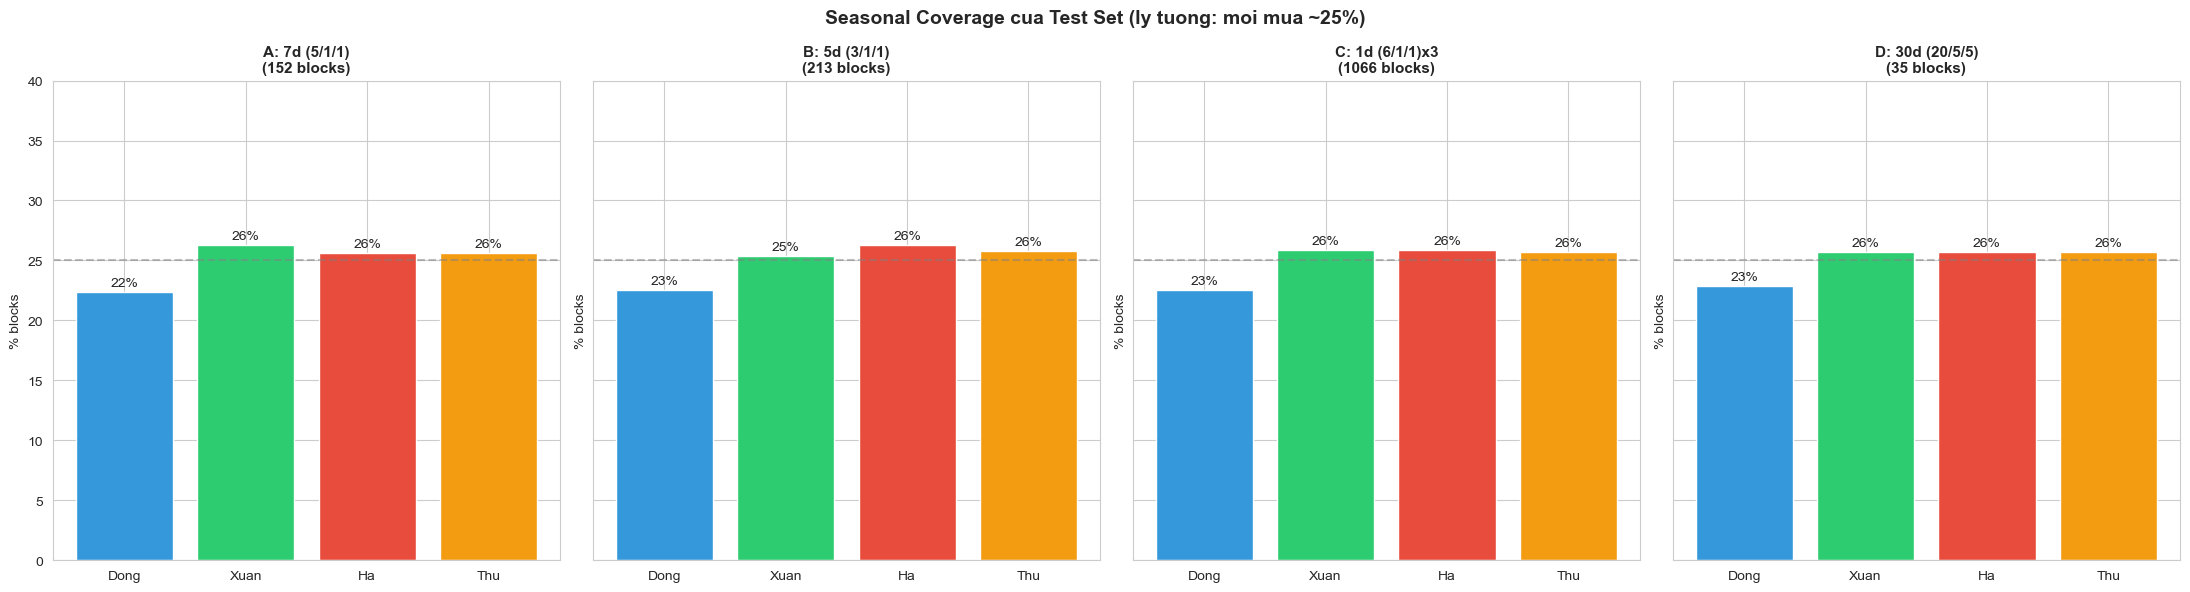

In [6]:

# === SEASONAL COVERAGE ===
fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharey=True)
seasons = ['DJF', 'MAM', 'JJA', 'SON']
season_labels = ['Dong', 'Xuan', 'Ha', 'Thu']

for ax, (bname, bconf) in zip(axes, BLOCKS.items()):
    r = all_results[bname][1]  # Use station 1 as reference
    if r:
        counts = [r['seasons'][s] for s in seasons]
        total = sum(counts)
        pcts = [c/total*100 if total > 0 else 0 for c in counts]
        bars = ax.bar(season_labels, pcts, color=['#3498db','#2ecc71','#e74c3c','#f39c12'])
        ax.axhline(y=25, color='gray', linestyle='--', alpha=0.5)
        ax.set_title(f'{bname}\n({total} blocks)', fontsize=11, fontweight='bold')
        ax.set_ylabel('% blocks')
        ax.set_ylim(0, 40)
        for bar, p in zip(bars, pcts):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, 
                   f'{p:.0f}%', ha='center', fontsize=10)

plt.suptitle('Seasonal Coverage cua Test Set (ly tuong: moi mua ~25%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Số lượng Block (Samples) — Đủ data training không?

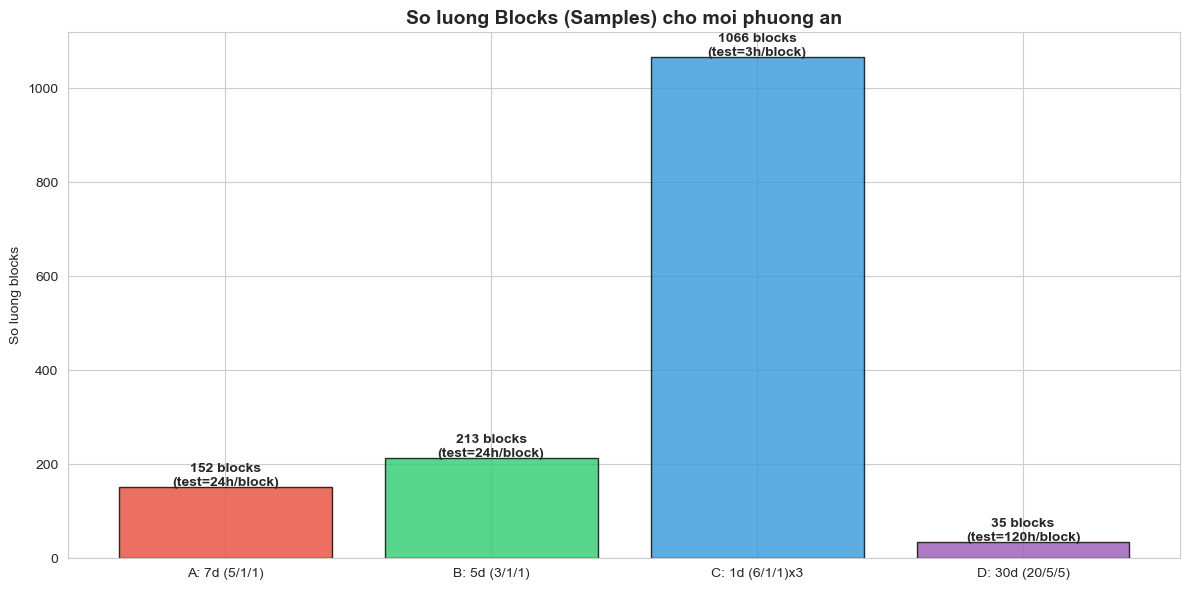


BANG TONG HOP SO SANH 4 PHUONG AN
Metric                         |    A: 7d (5/1/1) |    B: 5d (3/1/1) |  C: 1d (6/1/1)x3 |  D: 30d (20/5/5)
------------------------------------------------------------------------------------------
Avg MAE/Mean (BAC)             |           54.5% |           52.8% |           37.4% |           63.9%
Avg MAE/Mean (NAM)             |           43.0% |           40.0% |           29.2% |           54.6%
Avg Corr Train-Test (ALL)      |           0.607 |           0.678 |           0.956 |           0.633
Max Corr (worst leak)          |           0.735 |           0.900 |           0.996 |           0.837
Num Blocks                     |             152 |             213 |            1066 |              35
Test hours / block             |             24h |             24h |              3h |            120h
Season balance (std%)          |            1.5% |            1.5% |            1.4% |            1.2%


In [7]:

# === SAMPLE COUNT ===
fig, ax = plt.subplots(figsize=(12, 6))

block_names = list(BLOCKS.keys())
n_blocks_list = []
test_hours_list = []

for bname in BLOCKS:
    r = all_results[bname][1]
    n_blocks_list.append(r['n_blocks'] if r else 0)
    bconf = BLOCKS[bname]
    reps = bconf.get('repeats', 1)
    test_hours_list.append(bconf['test_h'] * reps)

colors = [BLOCKS[b]['color'] for b in block_names]
bars = ax.bar(block_names, n_blocks_list, color=colors, alpha=0.8, edgecolor='black')
for bar, n, th in zip(bars, n_blocks_list, test_hours_list):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
           f'{n} blocks\n(test={th}h/block)', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('So luong blocks')
ax.set_title('So luong Blocks (Samples) cho moi phuong an', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "=" * 90)
print("BANG TONG HOP SO SANH 4 PHUONG AN")
print("=" * 90)
print(f"{'Metric':30s}", end="")
for bname in BLOCKS:
    print(f" | {bname:>16s}", end="")
print()
print("-" * 90)

# Avg MAE/Mean
print(f"{'Avg MAE/Mean (BAC)':30s}", end="")
for bname in BLOCKS:
    vals = [all_results[bname][s]['mae_ratio'] for s in NORTH if all_results[bname][s]]
    print(f" | {np.mean(vals):14.1f}%", end="")
print()

print(f"{'Avg MAE/Mean (NAM)':30s}", end="")
for bname in BLOCKS:
    vals = [all_results[bname][s]['mae_ratio'] for s in SOUTH if all_results[bname][s]]
    print(f" | {np.mean(vals):14.1f}%", end="")
print()

print(f"{'Avg Corr Train-Test (ALL)':30s}", end="")
for bname in BLOCKS:
    vals = [all_results[bname][s]['corr'] for s in SELECTED if all_results[bname][s]]
    print(f" | {np.mean(vals):15.3f}", end="")
print()

print(f"{'Max Corr (worst leak)':30s}", end="")
for bname in BLOCKS:
    vals = [all_results[bname][s]['corr'] for s in SELECTED if all_results[bname][s]]
    print(f" | {max(vals):15.3f}", end="")
print()

print(f"{'Num Blocks':30s}", end="")
for bname in BLOCKS:
    r = all_results[bname][1]
    print(f" | {r['n_blocks']:>15d}", end="")
print()

print(f"{'Test hours / block':30s}", end="")
for bname in BLOCKS:
    bconf = BLOCKS[bname]
    reps = bconf.get('repeats', 1)
    th = bconf['test_h'] * reps
    print(f" | {th:>14d}h", end="")
print()

print(f"{'Season balance (std%)':30s}", end="")
for bname in BLOCKS:
    r = all_results[bname][1]
    if r:
        pcts = [r['seasons'][s]/r['n_blocks']*100 for s in ['DJF','MAM','JJA','SON']]
        print(f" | {np.std(pcts):14.1f}%", end="")
print()
print("=" * 90)


## 7. Visual: Block Overlay trên PM2.5 Timeline (2 tháng zoom)

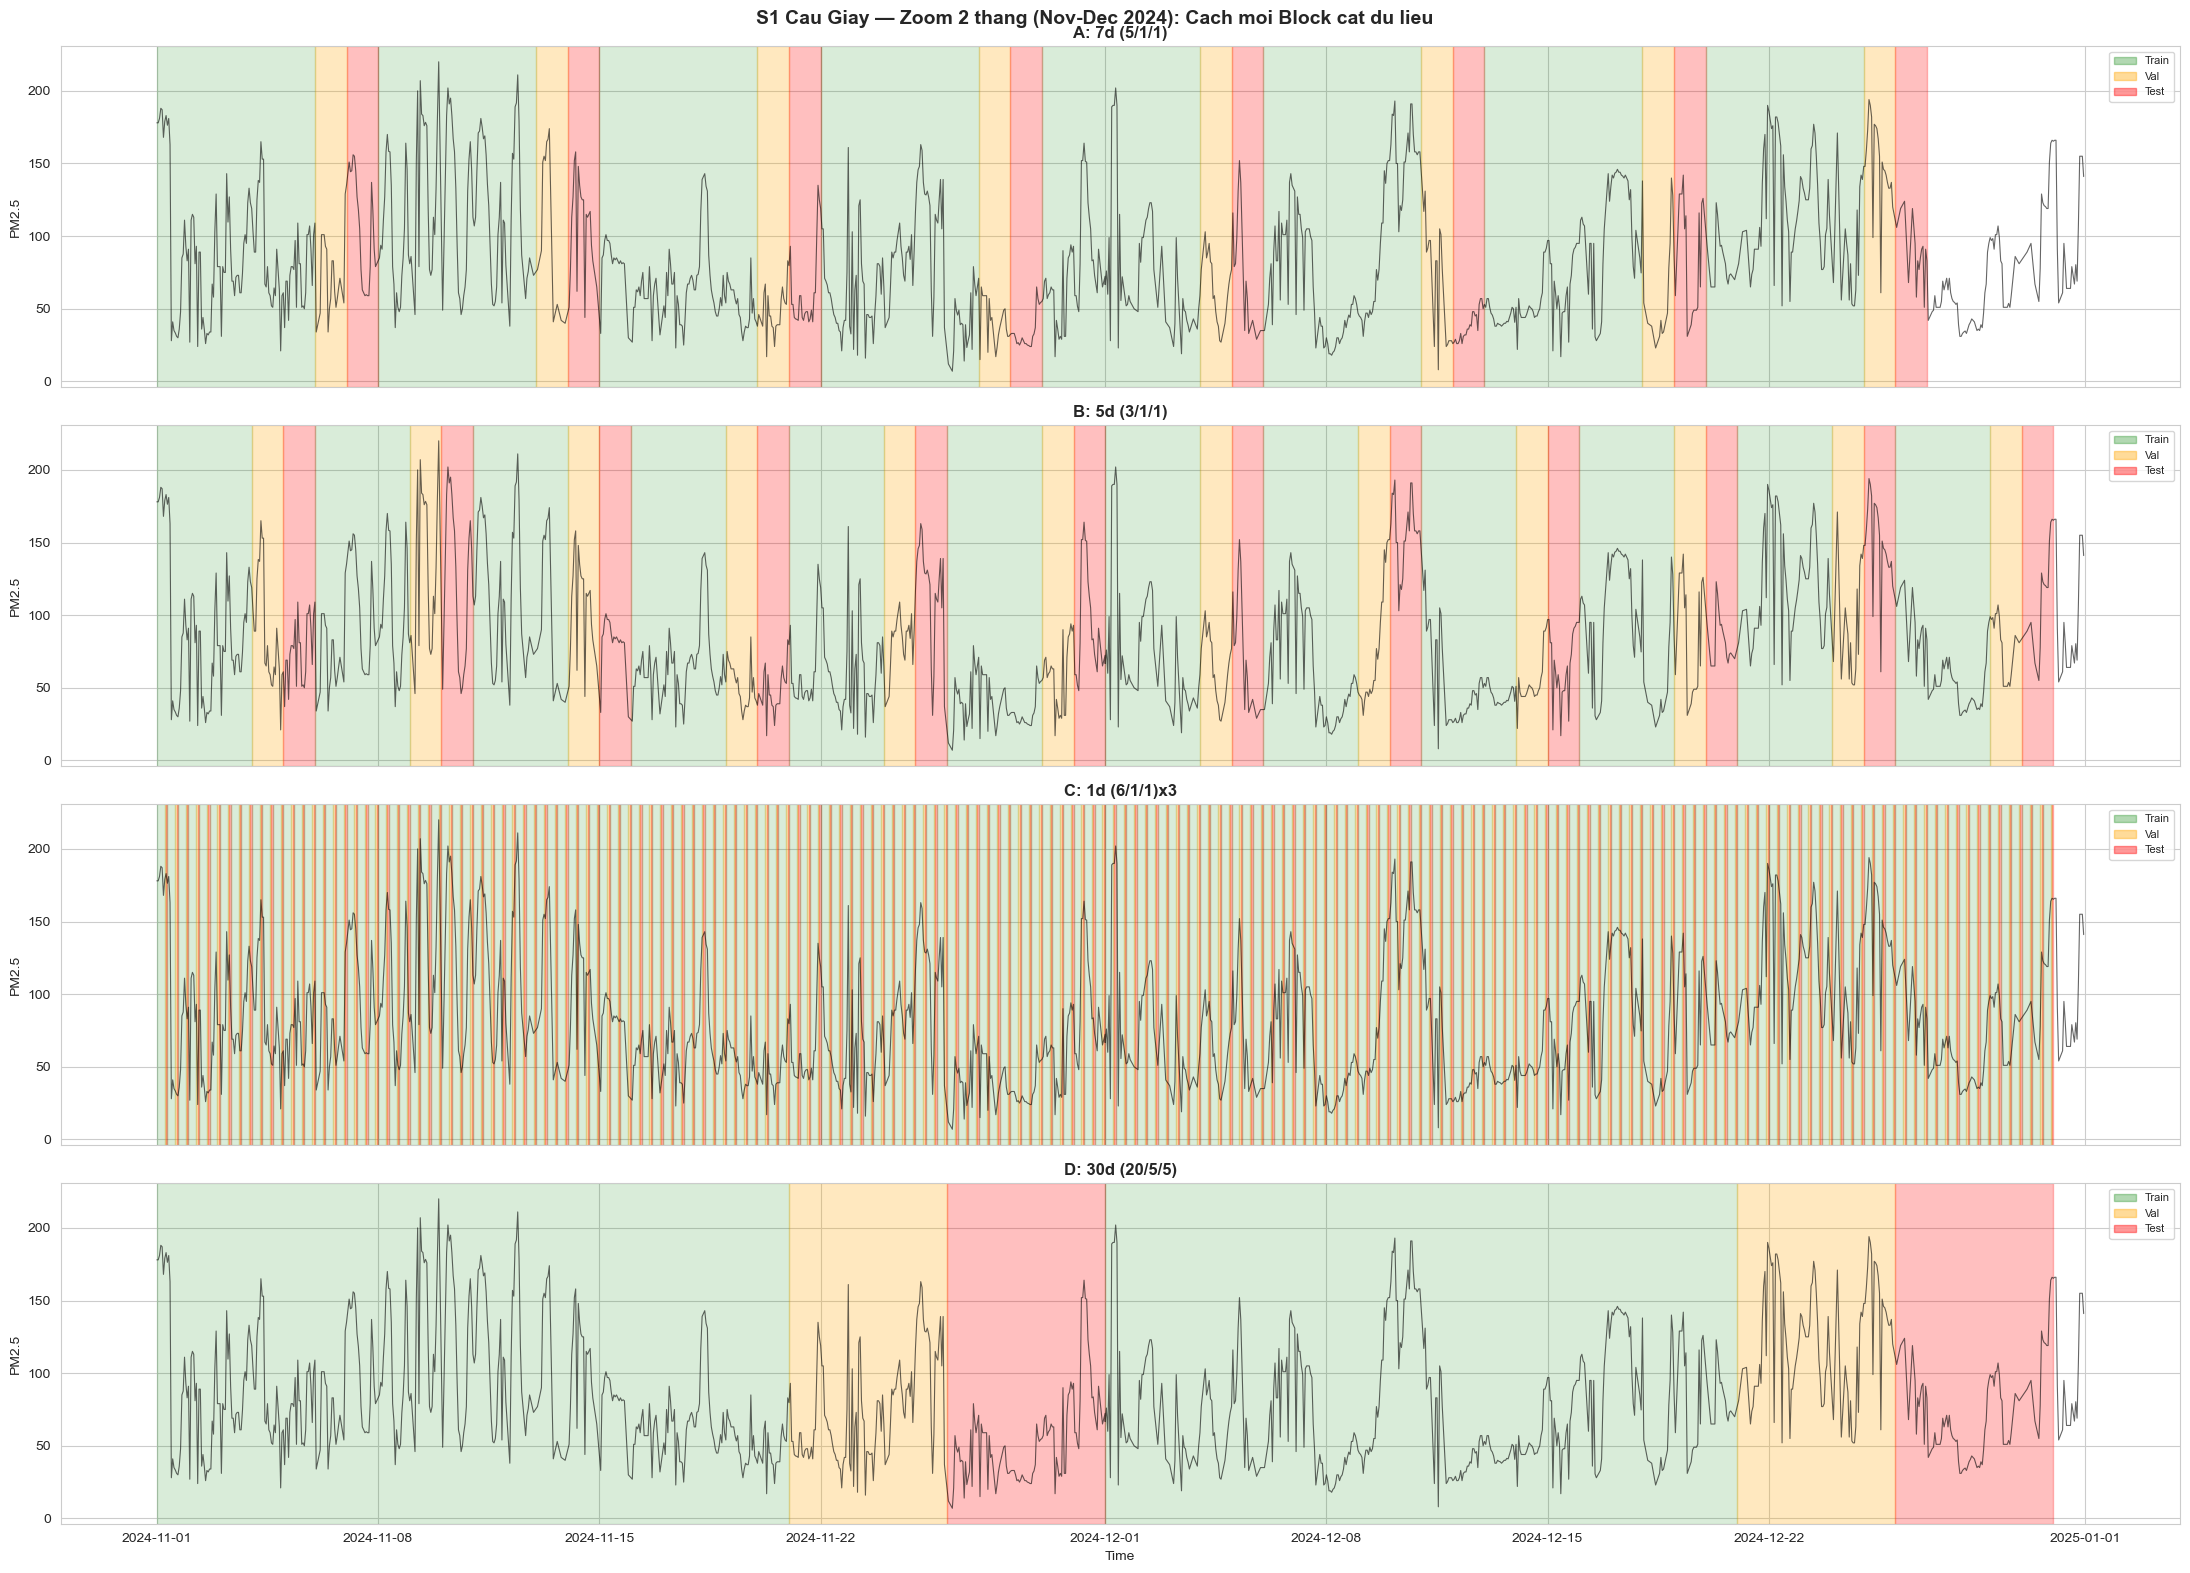

In [8]:

# === VISUAL: Show how blocks look on actual PM2.5 data ===
fig, axes = plt.subplots(4, 1, figsize=(22, 16), sharex=True)

pm1 = all_air[1].loc['2024-11-01':'2024-12-31']

for ax, (bname, bconf) in zip(axes, BLOCKS.items()):
    ax.plot(pm1.index, pm1.values, color='black', linewidth=0.8, alpha=0.6)
    
    train_h = bconf['train_h']
    val_h = bconf['val_h']
    test_h = bconf['test_h']
    repeats = bconf.get('repeats', 1)
    block_h = (train_h + val_h + test_h) * repeats
    
    start = pm1.index[0]
    block_num = 0
    while start + pd.Timedelta(hours=block_h) <= pm1.index[-1]:
        for r in range(repeats):
            offset_h = r * (train_h + val_h + test_h)
            t_start = start + pd.Timedelta(hours=offset_h)
            t_val = t_start + pd.Timedelta(hours=train_h)
            t_test = t_val + pd.Timedelta(hours=val_h)
            t_end = t_test + pd.Timedelta(hours=test_h)
            
            ax.axvspan(t_start, t_val, alpha=0.15, color='green')
            ax.axvspan(t_val, t_test, alpha=0.25, color='orange')
            ax.axvspan(t_test, t_end, alpha=0.25, color='red')
        
        start = start + pd.Timedelta(hours=block_h)
        block_num += 1
    
    ax.set_title(f'{bname}', fontsize=12, fontweight='bold')
    ax.set_ylabel('PM2.5')
    
    patches = [mpatches.Patch(color='green', alpha=0.3, label='Train'),
               mpatches.Patch(color='orange', alpha=0.4, label='Val'),
               mpatches.Patch(color='red', alpha=0.4, label='Test')]
    ax.legend(handles=patches, fontsize=8, loc='upper right')

axes[-1].set_xlabel('Time')
plt.suptitle('S1 Cau Giay — Zoom 2 thang (Nov-Dec 2024): Cach moi Block cat du lieu',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
